**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 02. Distribution Fitting
This notebook shows how to fit probability distributions to data using Numerics.

## What You'll Learn
- Method of Moments (MOM)
- Maximum Likelihood Estimation (MLE)
- L-Moments
- Comparing Fitted Distributions
- Goodness-of-Fit Diagnostics

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Numerics DLL (auto-discovered from NuGet; see notebook 00 for details)
from helper_functions import resolve_numerics_dll
clr.AddReference(str(resolve_numerics_dll()))

from Numerics.Distributions import Normal, LogNormal, GeneralizedExtremeValue, ParameterEstimationMethod
from Numerics.Data.Statistics import GoodnessOfFit, PlottingPositions

from helper_functions import convert_to_dotnet_array

print("✓ Setup complete for distribution fitting")

✓ Setup complete for distribution fitting


## Helper Function
The function below is to help plot the histogram of the data with the PDF of the fitted distribution. Graphing a PDF is covered in 01. Distributions.

In [2]:
def plot_empirical_vs_model(data, dist, title="Empirical vs Fitted Distribution"):
    """Plot histogram of data and PDF of fitted distribution."""
    x = np.linspace(min(data), max(data), 500)
    pdf = [dist.PDF(xi) for xi in x]

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=20, density=True, alpha=0.5, color="gray", edgecolor="black", label="Empirical")
    plt.plot(x, pdf, "r-", linewidth=2, label="Fitted PDF")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Example Data: Flood Peaks
We'll simulate annual peak flows using a Log-Normal Distribution.

Sample size: 100
Sample mean: 158155878.08
Sample std:  213541263.95


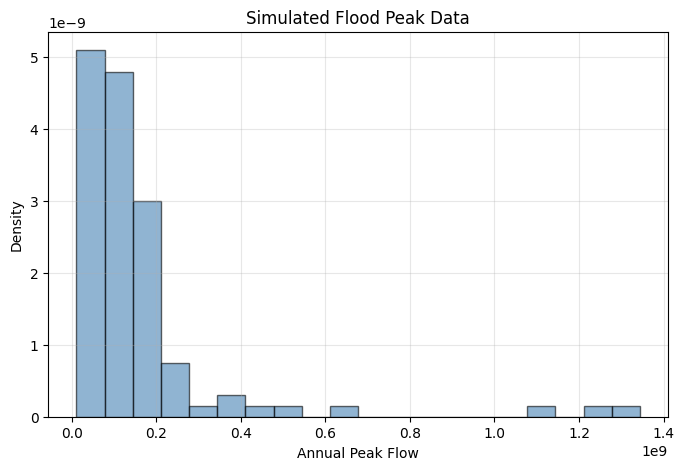

In [3]:
lognormal = LogNormal(8, 0.5)
data = lognormal.GenerateRandomValues(100,123)
print(f"Sample size: {len(data)}")
print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std:  {np.std(data):.2f}")

plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="black")
plt.xlabel("Annual Peak Flow")
plt.ylabel("Density")
plt.title("Simulated Flood Peak Data")
plt.grid(True, alpha=0.3)
plt.show()

## Method of Moments (MOM)
The Method of Moments (MOM) is the oldest and simplest approach to parameter estimation. The core idea is to equate sample moments to the corresponding theoretical moments of the distribution and solve for the unknown parameters [[1]](#1).

### Mathematical Formulation

Given a sample $x_1, x_2, \ldots, x_n$, the first four sample moments are the mean, standard deviation, skewness, and kurtosis:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

$$
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

$$
\hat{\gamma} = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3
$$

$$
\hat{\kappa} = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}
$$

The `Statistics.ProductMoments()` method returns these four quantities as the array $[\bar{x}, s, \hat{\gamma}, \hat{\kappa}]$.

MOM estimation sets the theoretical moments equal to the sample moments and solves for the distribution parameters. For a two-parameter distribution, only the first two moments (mean and standard deviation) are needed. For three-parameter distributions, skewness is also required.

Example: The Normal($\mu$, $\sigma$) has $E[X] = \mu$ and $\text{SD}[X] = \sigma$. Equating sample to theoretical moments yields:

$$
\hat{\mu} = \bar{x}, \quad \hat{\sigma} = s
$$

Example: The Gamma($\kappa$, $\theta$) has $E[X] = \kappa\theta$ and $\text{Var}[X] = \kappa\theta^2$. Solving for the parameters:

$$
\hat{\kappa} = \frac{\bar{x}^2}{s^2}, \quad \hat{\theta} = \frac{s^2}{\bar{x}}
$$

**Strengths:** Simple, closed-form solutions, always produces estimates, computationally fast.

**Weaknesses:** Not statistically efficient (higher variance than MLE), can produce invalid parameters for skewed distributions, estimates are sensitive to outliers because conventional moments give disproportionate weight to extreme values.

Now, we will fit a new LogNormal distribution to the data using sample mean and variance.

MOM Fit: mu=150193934.68, sigma=162945821.98


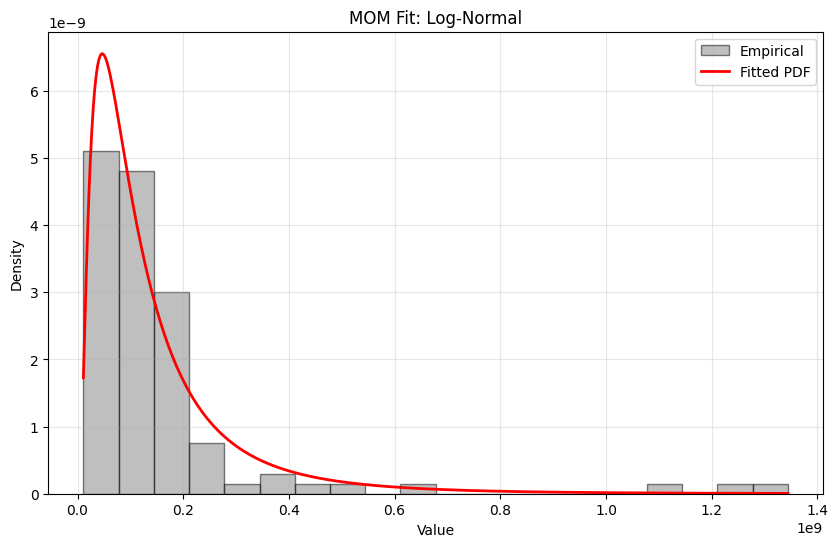

In [4]:
net_data = convert_to_dotnet_array(data)

mom_log = LogNormal()
mom_log.Estimate(net_data, ParameterEstimationMethod.MethodOfMoments)

print(f"MOM Fit: mu={mom_log.Mean:.2f}, sigma={mom_log.StandardDeviation:.2f}")
plot_empirical_vs_model(data, mom_log, title="MOM Fit: Log-Normal")

## Likelihood Estimation (MLE) 
Maximum Likelihood Estimation (MLE) finds the parameter values that make the observed data most probable under the assumed model [[2]](#2) [[3]](#3).

### Mathematical Formulation

Given independent observations $x_1, x_2, \ldots, x_n$ from a distribution with PDF $f(x|\boldsymbol{\theta})$, the likelihood function is the joint probability of the data viewed as a function of the parameters:

$$
L(\boldsymbol{\theta} \,|\, \mathbf{x}) = \prod_{i=1}^{n} f(x_i \,|\, \boldsymbol{\theta})
$$

Because products are numerically unstable, optimization is performed on the log-likelihood:

$$
\ell(\boldsymbol{\theta}) = \sum_{i=1}^{n} \log f(x_i \,|\, \boldsymbol{\theta})
$$

The MLE is the parameter vector that maximizes the log-likelihood:

$$
\hat{\boldsymbol{\theta}}_{\text{MLE}} = \underset{\boldsymbol{\theta}}{\text{argmax}} \; \ell(\boldsymbol{\theta})
$$

For some distributions (e.g., Normal, Exponential), the MLE has a closed-form solution. For most distributions used in hydrology (GEV, LP3, Weibull), the optimization must be solved numerically. The library uses constrained optimization with initial values derived from L-moment estimates.

The Fisher Information matrix quantifies the curvature of the log-likelihood surface at the maximum:

$$
\mathcal{I}(\boldsymbol{\theta}) = -E\left[\frac{\partial^2 \ell}{\partial \boldsymbol{\theta} \, \partial \boldsymbol{\theta}^T}\right]
$$

Under regularity conditions, the MLE is asymptotically normal [[4]](#4):

$$
\sqrt{n}\left(\hat{\boldsymbol{\theta}} - \boldsymbol{\theta}\right) \xrightarrow{d} N\left(\mathbf{0},\; \mathcal{I}(\boldsymbol{\theta})^{-1}\right) \quad \text{as } n \to \infty
$$

This provides approximate standard errors for each parameter:

$$
\text{SE}(\hat{\theta}_j) \approx \frac{1}{\sqrt{\mathcal{I}(\hat{\boldsymbol{\theta}})_{jj}}}
$$

**Strengths:** Asymptotically efficient (achieves the lowest possible variance among consistent estimators), asymptotically unbiased, invariant under reparameterization, provides a natural framework for model comparison via AIC and BIC.

**Weaknesses:** Requires numerical optimization that may fail to converge, sensitive to outliers, can be biased and inefficient for small samples, requires specification of the full probability model.

Continuing with our example, we will estimate LogNormal parameters using maximum likelihood.

MLE Fit: mu=149606124.89, sigma=0.38


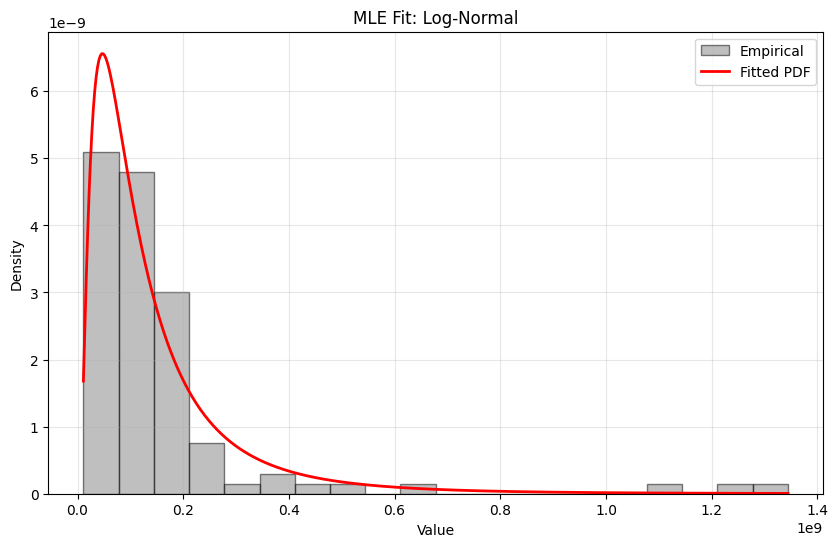

In [5]:
mle_log = LogNormal()
mle_log.Estimate(net_data, ParameterEstimationMethod.MaximumLikelihood)

print(f"MLE Fit: mu={mle_log.Mean:.2f}, sigma={mle_log.Sigma:.2f}")
plot_empirical_vs_model(data, mle_log, title="MLE Fit: Log-Normal")

## L-Moments
L-moments are linear combinations of order statistics that provide robust alternatives to conventional moments [[5]](#5). They are especially valuable for:
- Small sample sizes (n < 50)
- Data with outliers
- Hydrological applications
- Extreme value analysis

### Mathematical Formulation

L-moments are defined through probability-weighted moments (PWMs). For a random variable $X$ with CDF $F(x)$, the probability-weighted moments are:

$$
\beta_r = E\left[X \cdot F(X)^r\right] = \int_0^1 x(F) \cdot F^r \, dF, \quad r = 0, 1, 2, \ldots
$$

The first four L-moments are linear combinations of the PWMs:

$$
\lambda_1 = \beta_0
$$

$$
\lambda_2 = 2\beta_1 - \beta_0
$$

$$
\lambda_3 = 6\beta_2 - 6\beta_1 + \beta_0
$$

$$
\lambda_4 = 20\beta_3 - 30\beta_2 + 12\beta_1 - \beta_0
$$

The L-moment ratios, which are dimensionless and bounded, are defined as:

$$
\tau = \frac{\lambda_2}{\lambda_1} \quad \text{(L-CV)}, \qquad \tau_3 = \frac{\lambda_3}{\lambda_2} \quad \text{(L-skewness)}, \qquad \tau_4 = \frac{\lambda_4}{\lambda_2} \quad \text{(L-kurtosis)}
$$

L-skewness is bounded in $[-1, 1]$ and L-kurtosis in $[\frac{1}{4}(5\tau_3^2 - 1),\; 1]$, unlike conventional skewness and kurtosis which are unbounded. This boundedness makes L-moment ratios more interpretable and stable.

Sample estimation: Given a sorted sample $x_{1:n} \leq x_{2:n} \leq \cdots \leq x_{n:n}$, the unbiased sample PWM estimators are:

$$
b_r = \frac{1}{n}\sum_{j=r+1}^{n} \frac{\binom{j-1}{r}}{\binom{n-1}{r}} \, x_{j:n}, \quad r = 0, 1, 2, \ldots
$$

The `Statistics.LinearMoments()` method computes these sample PWMs and returns the array $[\lambda_1, \lambda_2, \tau_3, \tau_4]$.

### Why L-moments are preferred for small samples
Conventional moments involve powers of deviations from the mean, so a single extreme observation can dominate the skewness or kurtosis estimate. L-moments use only linear combinations of order statistics, which makes them far more robust to outliers and nearly unbiased even for samples as small as $n = 10$. For hydrological applications where sample sizes are often 30--60 years of annual data, this robustness is critical.


Now we will demonstrate L-Moment fitting.

L-Moments Log-Normal fit: mu=147689495.62, sigma=0.37


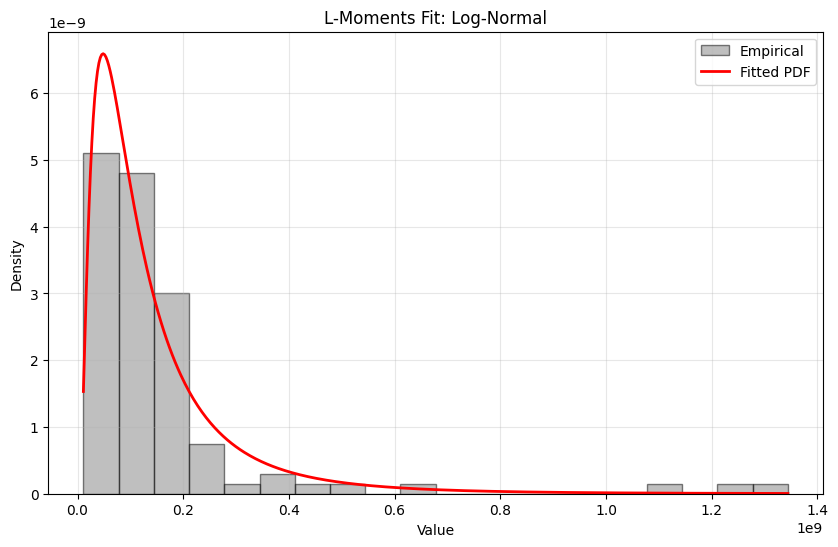

In [6]:
lm_log = LogNormal()

lm_log.Estimate(net_data, ParameterEstimationMethod.MethodOfLinearMoments)

print(f"L-Moments Log-Normal fit: mu={lm_log.Mean:.2f}, sigma={lm_log.Sigma:.2f}")
plot_empirical_vs_model(data, lm_log, title="L-Moments Fit: Log-Normal")

## Comparing Multiple Fits
We will compare three LogNormal fits from above (MOM, MLE, L-Moments) all together on our example data.

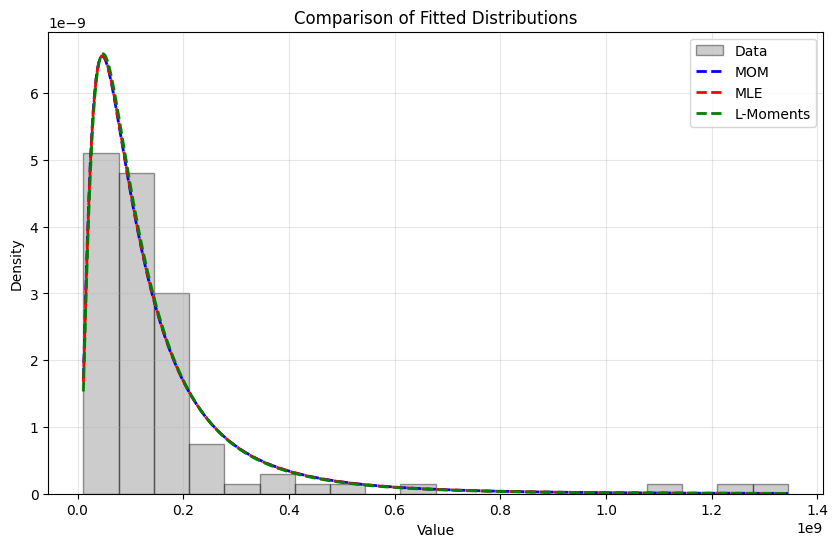

In [7]:
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=20, density=True, alpha=0.4, color="gray", edgecolor="black", label="Data")

# MOM Normal
mom_pdf = [mom_log.PDF(xi) for xi in x]
plt.plot(x, mom_pdf, "b--", linewidth=2, label="MOM")

# MLE LogNormal 
mle_pdf = [mle_log.PDF(xi) for xi in x]
plt.plot(x, mle_pdf, "r--", linewidth=2, label="MLE")


# L-Moments Log-Normal
lm_pdf = [lm_log.PDF(xi) for xi in x]
plt.plot(x, lm_pdf, "g--", linewidth=2, label="L-Moments")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Comparison of Fitted Distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Goodness of Fit Diagnostics
We can compute simple metrics, such as log-likelihood and AIC, for each model to compare model performance [[4]](#4), [[6]](#6). Recall a larger (less negative) log-likelihood and smaller AIC reflect a better fit to the data.

In [8]:
# Compute the log-likelihood of the fitted distribution
mom_ll = mom_log.LogLikelihood(net_data)
mle_ll = mle_log.LogLikelihood(net_data)
lm_ll = lm_log.LogLikelihood(net_data)

# Compute AIC - smaller is better
mom_aic = GoodnessOfFit.AIC(2, mom_ll)
mle_aic = GoodnessOfFit.AIC(2, mle_ll)
lm_aic = GoodnessOfFit.AIC(2, lm_ll)

# Compute BIC - smaller is better
mom_bic = GoodnessOfFit.BIC(len(data),2, mom_ll)
mle_bic = GoodnessOfFit.BIC(len(data),2, mle_ll)
lm_bic = GoodnessOfFit.BIC(len(data),2, lm_ll)

# Compute RMSE - smaller is better
mom_rmse = GoodnessOfFit.RMSE(net_data, mom_log)
mle_rmse = GoodnessOfFit.RMSE(net_data, mle_log)
lm_rmse = GoodnessOfFit.RMSE(net_data, lm_log)


results = pd.DataFrame({
    "Distribution": ["LogNormal (MOM)", "LogNormal (MLE)", "LogNormal (L-Moments)"],
    "Log-Likelihood": [mom_ll, mle_ll, lm_ll],  
    "AIC": [mom_aic, mle_aic, lm_aic],
    "BIC": [mom_bic, mle_bic, lm_bic],
    "RMSE": [mom_rmse, mle_rmse, lm_rmse]
})
display(results)


,Distribution,Log-Likelihood,AIC,BIC,RMSE
0,LogNormal (MOM),-1972.685554,3949.371109,3954.581449,5.995955e+07
1,LogNormal (MLE),-1972.683043,3949.366086,3954.576426,6.041398e+07
2,LogNormal (L-Moments),-1972.712513,3949.425026,3954.635366,6.193926e+07


## Plotting Fitted vs Empirical CDF
We compare the fitted CDFs to the empirical CDF to visually assess goodness of fit.

Empirical CDF (ECDF): for each sorted observation $x_i$, ECDF gives the fraction of observed values less than or equal to $x_i$, computed as $i/n$. 

Interpretation: if ECDF(x)=0.80, then about 80% of observations are $\leq x$.

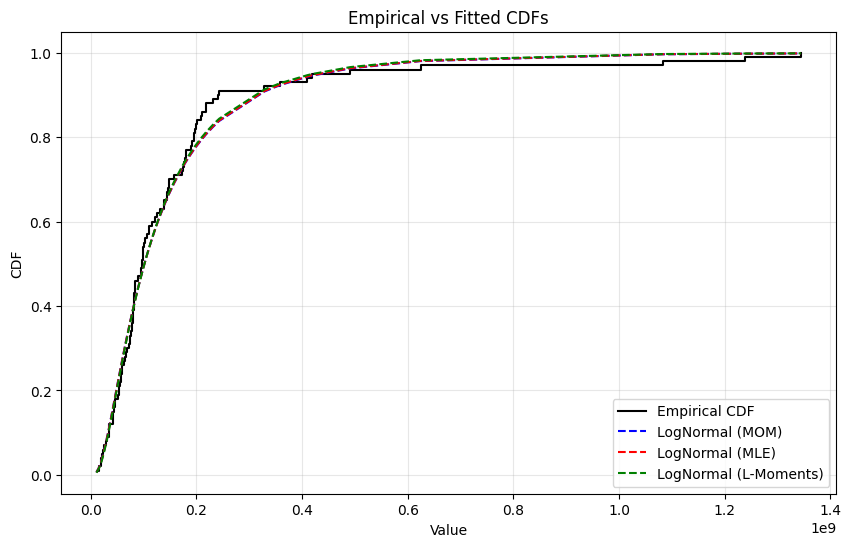

In [9]:
sorted_data = np.sort(data)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

plt.figure(figsize=(10, 6))
plt.step(sorted_data, empirical_cdf, where='post', label='Empirical CDF', color='black')

plt.plot(sorted_data, [mom_log.CDF(x) for x in sorted_data], "b--", label='LogNormal (MOM)')
plt.plot(sorted_data, [mle_log.CDF(x) for x in sorted_data], "r--", label='LogNormal (MLE)')
plt.plot(sorted_data, [lm_log.CDF(x) for x in sorted_data], "g--", label='LogNormal (L-Moments)')

plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical vs Fitted CDFs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Plotting Positions
Plotting positions assign each ordered observation an empirical nonexceedance probability, which lets us compare data to theoretical CDFs on probability paper and assess fit visually. They are also the basis for many hydrologic frequency plots and return-period calculations [[7]](#7).

A common choice is the Weibull plotting position, which maps the $i$-th smallest value $x_{(i)}$ in a sample of size $n$ to:
$$
p_i = \frac{i}{n+1}
$$
This gives evenly spaced nonexceedance probabilities and is widely used for empirical CDFs. Numerics provides built-in plotting position functions so you can compute these consistently [[7]](#7).


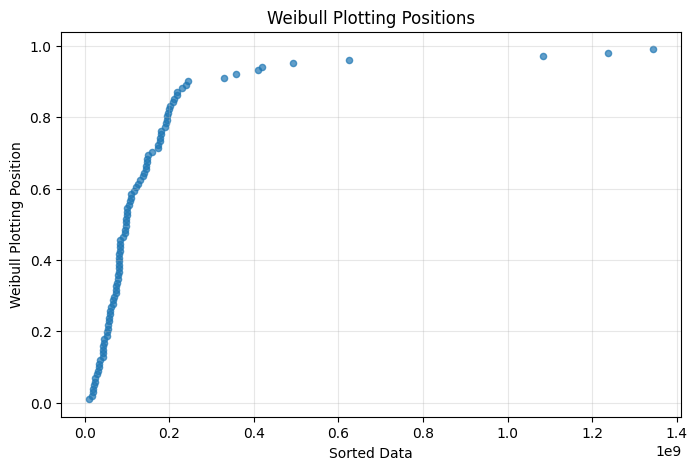

In [10]:
n = len(sorted_data)
weibull_pp = np.array(list(PlottingPositions.Weibull(n)))

plt.figure(figsize=(8, 5))
plt.scatter(sorted_data, weibull_pp, s=20, alpha=0.7)
plt.xlabel("Sorted Data")
plt.ylabel("Weibull Plotting Position")
plt.title("Weibull Plotting Positions")
plt.grid(True, alpha=0.3)
plt.show()


## Summary
You've learned:

$\checkmark$ How to fit distributions using Method of Moments (MOM), Maximum Likelihood (MLE), and L-Moments      
$\checkmark$ Compared fitted models using likelihood-based metrics (AIC/BIC) and RMSE     
$\checkmark$ Visualized fits against data.        

## Exercise
1. Generate synthetic data from a Weibull distribution
2. Fit Weibull parameters using MLE and L-Moments
3. Compare fit quality with AIC/BIC

## References

<a id="1">[1]</a> A. M. Mood, F. A. Graybill, and D. C. Boes, *Introduction to the Theory of Statistics*, 3rd ed. McGraw-Hill, 1974.

<a id="2">[2]</a> G. Casella and R. L. Berger, *Statistical Inference*, 2nd ed. Duxbury/Thomson, 2002.

<a id="3">[3]</a> Y. Pawitan, *In All Likelihood: Statistical Modelling and Inference Using Likelihood*. Oxford University Press, 2001.

<a id="4">[4]</a> H. Akaike, "A new look at the statistical model identification," *IEEE Transactions on Automatic Control*, vol. 19, no. 6, pp. 716-723, 1974.

<a id="5">[5]</a> J. R. M. Hosking, "L-moments: Analysis and estimation of distributions using linear combinations of order statistics," *Journal of the Royal Statistical Society: Series B*, vol. 52, no. 1, pp. 105-124, 1990.

<a id="6">[6]</a> G. Schwarz, "Estimating the dimension of a model," *Annals of Statistics*, vol. 6, no. 2, pp. 461-464, 1978.

<a id="7">[7]</a> U.S. Army Corps of Engineers Risk Management Center, *Numerics Library Documentation: Parameter Estimation and Plotting Positions*, 2026.
